In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape

I0000 00:00:1774597386.156505  657706 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774597386.236174  657706 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774597387.814292  657706 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(60000, 28, 28)

In [3]:
X_test.shape

(10000, 28, 28)

# 픽셀값 정규화

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# 합성곱 신경망의 구조

In [5]:
from tensorflow.keras import Sequential, layers
model = Sequential(
  [
    layers.Input(shape=(28,28,1)), #3차원 이미지 1장의 입력

    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(), 
    layers.Dropout(0.1),
    
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #분류 계층
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
  ]
)
model.summary

I0000 00:00:1774597389.650781  657706 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


<bound method Model.summary of <Sequential name=sequential, built=True>>

In [6]:
model.layers[0].get_weights()

[array([[[[ 0.02582294,  0.04156561,  0.01704201,  0.04726844,
           -0.01762582,  0.00972597,  0.06802145, -0.11870133,
           -0.11121839,  0.04543869,  0.02372673, -0.10030878,
           -0.03203225,  0.07336098,  0.05560879, -0.12209183,
           -0.13216864, -0.04858997,  0.08683886,  0.04455729,
           -0.10267533, -0.03802451,  0.10204469, -0.12160249,
            0.1176724 ,  0.12986197,  0.08545375, -0.02001823,
            0.04579133, -0.01719586,  0.05948001, -0.06770339]],
 
         [[ 0.01898034,  0.12649538, -0.13043523,  0.00859675,
            0.03856516, -0.12681243, -0.04934136, -0.07286541,
            0.10242239,  0.14145349, -0.0272585 ,  0.06389315,
           -0.11403355, -0.10850914,  0.11150528, -0.04937237,
           -0.01700765, -0.02152371,  0.06170048,  0.01259483,
           -0.00411467,  0.12277879, -0.01170899, -0.00612423,
            0.08494167, -0.03960126,  0.05429856,  0.00136963,
           -0.06074432,  0.0466764 ,  0.12583007,  

In [7]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])

In [8]:
history = model.fit(X_train, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10


I0000 00:00:1774597391.343695  657814 service.cc:153] XLA service 0x7af1cc032bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774597391.343721  657814 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774597391.361144  657814 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774597391.499931  657814 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774597391.552791  657814 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1791__.33


 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3815 - loss: 1.8638

I0000 00:00:1774597395.922835  657814 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8855 - loss: 0.3702 - val_accuracy: 0.9748 - val_loss: 0.0859
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9630 - loss: 0.1220 - val_accuracy: 0.9842 - val_loss: 0.0562
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9737 - loss: 0.0879 - val_accuracy: 0.9862 - val_loss: 0.0470
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.0745 - val_accuracy: 0.9880 - val_loss: 0.0405
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9806 - loss: 0.0649 - val_accuracy: 0.9885 - val_loss: 0.0400
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9829 - loss: 0.0554 - val_accuracy: 0.9893 - val_loss: 0.0372
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9835 - loss: 0.0525 - val_accuracy: 0.9896 - val_loss: 0.0353
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9848 - loss: 0.0489 - val_accuracy: 0.9901 - val_

In [9]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

In [10]:
print(f'Test loss: {loss}, Test accuracy: {accuracy}')

Test loss: 0.024790700525045395, Test accuracy: 0.9911999702453613


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 찾기
nanum_fonts = [f for f in fm.findSystemFonts() if 'Nanum' in f or 'nanum' in f]
print(nanum_fonts)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 한글 폰트 설정 완료')

['/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf']
✅ 한글 폰트 설정 완료


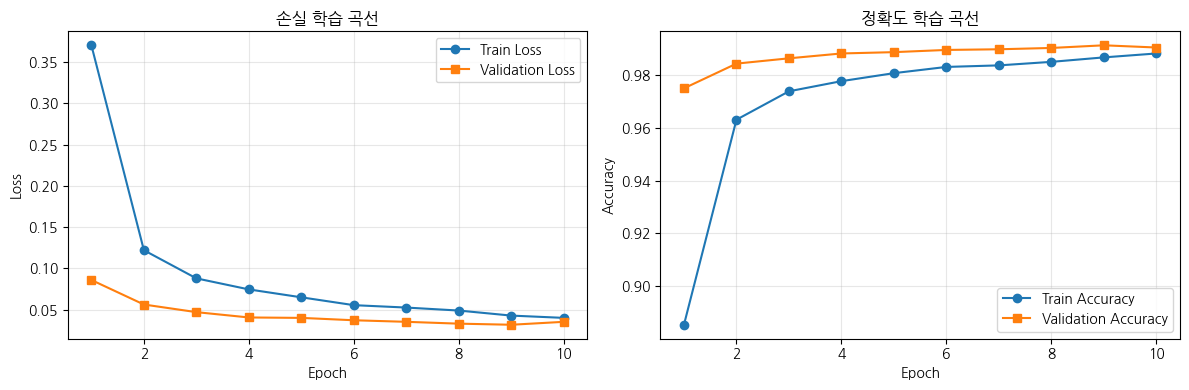

In [12]:
epochs = range(1, len(history.history['loss']) + 1)

train_acc = history.history.get('accuracy', history.history.get('acc'))
val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))
train_loss = history.history['loss']
val_loss = history.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, marker='o', label='Train Loss')
axes[0].plot(epochs, val_loss, marker='s', label='Validation Loss')
axes[0].set_title('손실 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, train_acc, marker='o', label='Train Accuracy')
axes[1].plot(epochs, val_acc, marker='s', label='Validation Accuracy')
axes[1].set_title('정확도 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


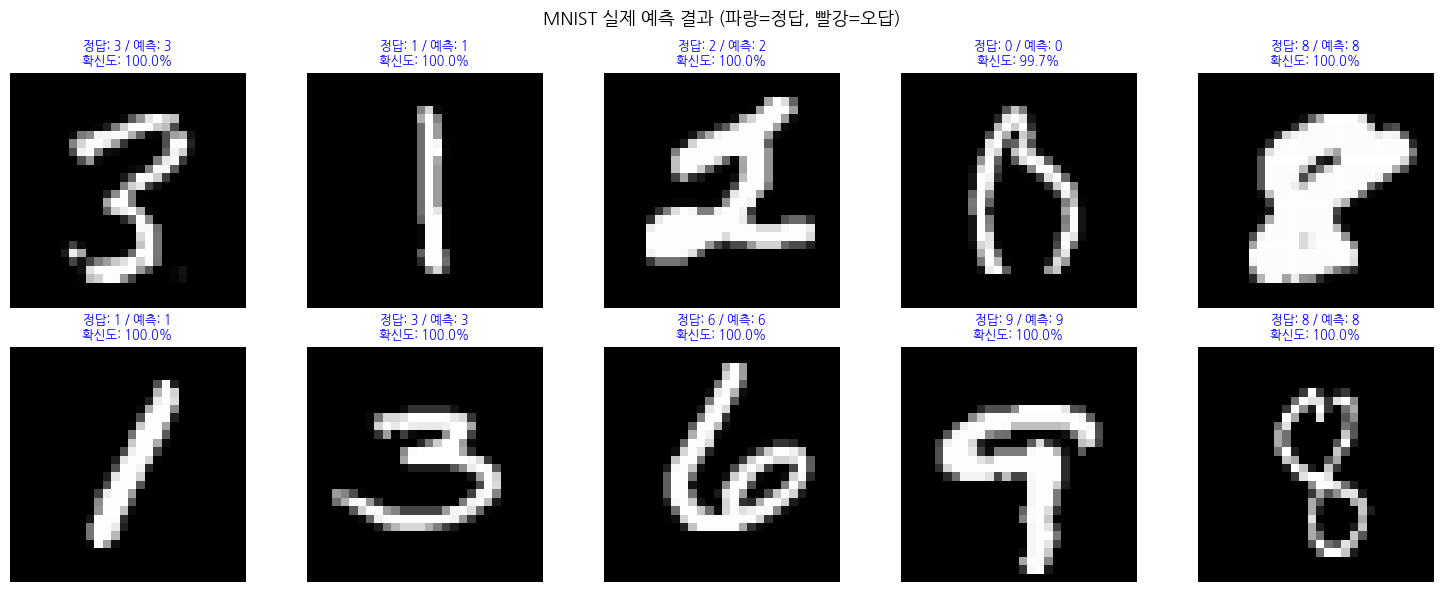

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 테스트 이미지 10개 랜덤 선택
indices = np.random.randint(0, len(X_test), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]
    
    # 예측
    pred_prob = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    pred_label = np.argmax(pred_prob)
    confidence = pred_prob[0][pred_label] * 100
    
    # 시각화
    axes[i].imshow(img.reshape(28, 28), cmap='gray')
    axes[i].set_title(
        f'정답: {true_label} / 예측: {pred_label}\n확신도: {confidence:.1f}%',
        color='blue' if true_label == pred_label else 'red',
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('MNIST 실제 예측 결과 (파랑=정답, 빨강=오답)', fontsize=13)
plt.tight_layout()
plt.show()